# Integrated dynamic SURF–topside–control simulation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/integrated_dynamic_surf_topside_control.ipynb)

This notebook builds one conservative dynamic chain from a subsea multiphase
flowline to topside compression. It uses **NeqSim Java built from current
`equinor/neqsim` `master`**, while the Python package is only the JPype bridge.

The solved teaching case couples:

- native `TwoFluidPipe` pressure, temperature, holdup, terrain accumulation,
  and Lagrangian slug tracking;
- native dynamic `Separator` pressure and liquid inventory;
- a generated native compressor map with surge and stonewall curves;
- native `AntiSurgeController` recycle demand;
- native `ControllerDeviceBaseClass` plant-pressure control through speed;
- a constraint override that prevents anti-surge recycle from crossing the
  compressor stonewall limit;
- an explicit steady-to-dynamic handover test that catches the sharp first
  step instead of silently accepting it.

The inputs are synthetic and intended for learning. They are not field design
data.

## Learning objectives and calculation contract

By the end, you will be able to:

1. build a terrain-dependent two-fluid transient from NeqSim Java `master`;
2. distinguish discrete conservation from state continuity at initialization;
3. condition a steady pipe state before coupling it downstream;
4. couple the native transient outlet stream directly to a dynamic vessel;
5. audit phase-resolved gas, oil, water, liquid, and total boundary fluxes;
6. operate a chart-based compressor with pressure and anti-surge control;
7. arbitrate surge protection against stonewall capacity; and
8. publish named, executable engineering gates.

One fresh Java `UUID` is used for every physical timestep and shared by all
equipment evaluated during that timestep. Reusing one identifier for a time
series can cause NeqSim equipment to regard later calculations as duplicates.

The pipe balance report closes each accepted step as

$$\begin{aligned}M_{k+1}-M_k&=m_{in,k}-m_{out,k}+m_{source,k}+r_k\end{aligned}$$

where the boundary and source masses are integrated using the same internal
Runge–Kutta weights as the conservative pipe state. The native outlet process
stream must expose the same interval-average total flux:

$$\dot m_{stream,k}=\frac{m_{out,k}^{total}}{\Delta t_k}$$

## 1. Build and load NeqSim Java `master`

The JVM must not start until the source-built JAR is on its classpath. In
Colab, the cell clones `equinor/neqsim`, resolves `master`, and packages the
JAR with the Maven wrapper. In a validation workspace, `NEQSIM_SOURCE_ROOT`
can point to an already-built checkout of the same source.

The cell records the resolved Git commit, JAR SHA-256, and the actual Java
class location. A main-only class is asserted so an older bundled JAR cannot
pass silently.

In [1]:
import hashlib
import importlib.util
import os
import platform
import subprocess
import sys
from pathlib import Path

NEQSIM_SOURCE_REF = "master"
NEQSIM_REPOSITORY = "https://github.com/equinor/neqsim.git"
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--upgrade",
            "neqsim",
        ]
    )

configured_root = os.environ.get("NEQSIM_SOURCE_ROOT")
if configured_root:
    source_root = Path(configured_root).resolve()
else:
    source_root = Path("/content/neqsim-java-master")
    if not source_root.exists():
        subprocess.check_call(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                NEQSIM_REPOSITORY,
                str(source_root),
            ]
        )

source_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    cwd=source_root,
    text=True,
).strip()
jar_path = source_root / "target" / "neqsim-3.16.0.jar"
if not jar_path.exists():
    subprocess.check_call(
        [
            str(source_root / "mvnw"),
            "-q",
            "-DskipTests",
            "-Dmaven.javadoc.skip=true",
            "package",
        ],
        cwd=source_root,
    )

jar_sha256 = hashlib.sha256(jar_path.read_bytes()).hexdigest()

import jpype

jpype.addClassPath(str(jar_path))
from neqsim.neqsimpython import init_jvm

init_jvm(["-Xrs", "-XX:-UsePerfData"])
J = jpype.JClass

TwoFluidMassBalanceReport = J(
    "neqsim.process.equipment.pipeline.TwoFluidMassBalanceReport"
)
LagrangianSlugTracker = J(
    "neqsim.process.equipment.pipeline.twophasepipe."
    "LagrangianSlugTracker"
)
assert hasattr(LagrangianSlugTracker, "getTotalMassExitedAtOutlet")
loaded_uri = (
    TwoFluidMassBalanceReport.class_
    .getProtectionDomain()
    .getCodeSource()
    .getLocation()
    .toURI()
)
loaded_jar = Path(str(loaded_uri.getPath())).resolve()
assert loaded_jar == jar_path.resolve()

provenance = {
    "requested ref": NEQSIM_SOURCE_REF,
    "resolved commit": source_commit,
    "runtime JAR": jar_path.name,
    "JAR SHA-256": jar_sha256,
    "loaded class location": str(loaded_jar),
    "Python": platform.python_version(),
    "Java": str(J("java.lang.System").getProperty("java.version")),
}
provenance

{'requested ref': 'master',
 'resolved commit': '7ae08253b45180045a99a700314f23c9a7001b3c',
 'runtime JAR': 'neqsim-3.16.0.jar',
 'JAR SHA-256': '174ba787649c63b3d709ce439bd326284aa91861adaaf6b8d164816ce3c7db3c',
 'loaded class location': '/workspace/scratch/3a96a9f11937/NeqSim-Colab/neqsim-java-master/target/neqsim-3.16.0.jar',
 'Python': '3.12.13',
 'Java': '17.0.19'}

## 2. Imports, native APIs, and plotting style

Every NeqSim class below comes from the source-built Java JAR. NumPy and
pandas orchestrate the co-simulation, calculate transparent supervisory logic,
and organize evidence; they do not replace thermodynamics, pipe conservation,
separator dynamics, compressor maps, or the native controllers.

In [2]:
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SystemSrkEos = J("neqsim.thermo.system.SystemSrkEos")
Stream = J("neqsim.process.equipment.stream.Stream")
TwoFluidPipe = J("neqsim.process.equipment.pipeline.TwoFluidPipe")
BoundaryCondition = J(
    "neqsim.process.equipment.pipeline.TwoFluidPipe$BoundaryCondition"
)
SlugTrackingMode = J(
    "neqsim.process.equipment.pipeline.TwoFluidPipe$SlugTrackingMode"
)
Phase = J(
    "neqsim.process.equipment.pipeline."
    "TwoFluidMassBalanceReport$Phase"
)
Separator = J("neqsim.process.equipment.separator.Separator")
LevelTransmitter = J("neqsim.process.measurementdevice.LevelTransmitter")
Compressor = J("neqsim.process.equipment.compressor.Compressor")
CompressorChartGenerator = J(
    "neqsim.process.equipment.compressor.CompressorChartGenerator"
)
PressureTransmitter = J(
    "neqsim.process.measurementdevice.PressureTransmitter"
)
Controller = J(
    "neqsim.process.controllerdevice.ControllerDeviceBaseClass"
)
ThrottlingValve = J("neqsim.process.equipment.valve.ThrottlingValve")
AntiSurgeController = J(
    "neqsim.process.controllerdevice.AntiSurgeController"
)
JavaUUID = J("java.util.UUID")


def new_step_id():
    """Return a fresh Java identifier for one physical timestep."""
    return JavaUUID.randomUUID()


plt.rcParams.update(
    {
        "axes.grid": True,
        "figure.dpi": 115,
        "grid.alpha": 0.25,
        "lines.linewidth": 1.8,
    }
)
COLORS = {
    "blue": "#1F77B4",
    "orange": "#E67E22",
    "green": "#2CA02C",
    "red": "#C44E52",
    "purple": "#8172B3",
    "gray": "#5B6573",
}

## 3. System architecture and modelling boundary

Current NeqSim `master` publishes the accepted interval-average total boundary
flux through `TwoFluidPipe.getOutletStream()`. The notebook therefore couples
that native process stream directly to the separator, preserving its
thermodynamic state, composition, pressure, temperature, and total flow.

`TwoFluidMassBalanceReport` remains an independent, phase-resolved audit. At
every step the notebook requires the stream total to match the report total and
requires gas plus liquid to reproduce the multiphase total. These checks are
regressions for the corrections merged in NeqSim PR #2816.

The separator gas is copied into a compressor suction stream so recycle can be
added without mutating the separator outlet. The native anti-surge controller
requests recycle opening. A low-select override caps actual recycle at 95% of
the conservative stonewall capacity. The pressure controller adjusts speed.

$$\dot m_{K}=\dot m_{fresh}+\dot m_{recycle}$$

$$\begin{aligned}\dot m_{recycle,target}&=\min\left(\dot m_{ASC},\ 0.95\dot m_{stonewall}-\dot m_{fresh}\right)\end{aligned}$$

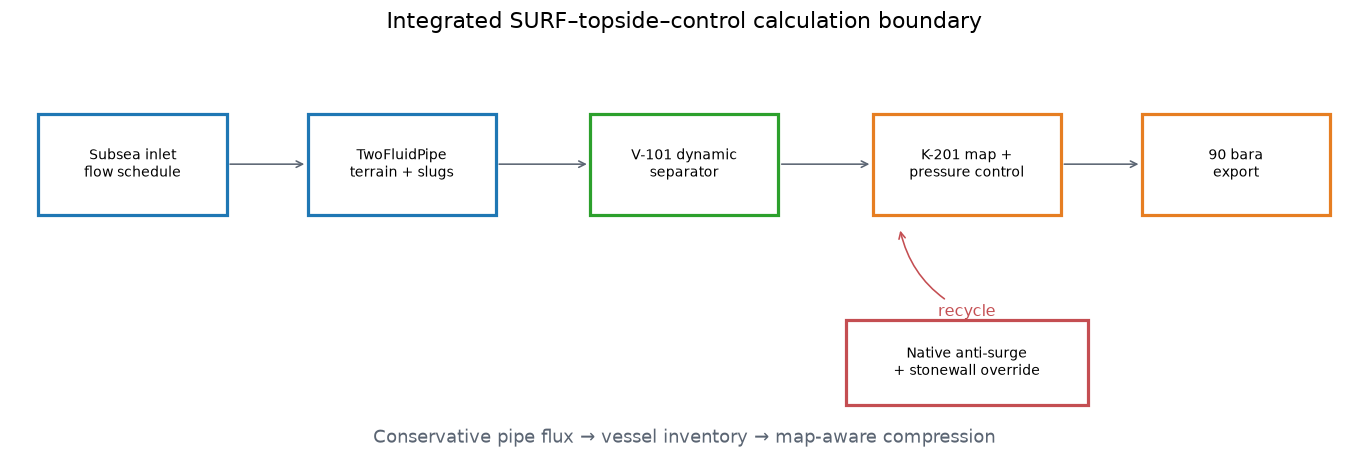

In [3]:
figure, axis = plt.subplots(figsize=(12.0, 4.2))
axis.axis("off")

boxes = [
    (0.02, 0.58, "Subsea inlet\nflow schedule", COLORS["blue"]),
    (0.22, 0.58, "TwoFluidPipe\nterrain + slugs", COLORS["blue"]),
    (0.43, 0.58, "V-101 dynamic\nseparator", COLORS["green"]),
    (0.64, 0.58, "K-201 map +\npressure control", COLORS["orange"]),
    (0.84, 0.58, "90 bara\nexport", COLORS["orange"]),
]
for x_value, y_value, label, color in boxes:
    axis.add_patch(
        plt.Rectangle(
            (x_value, y_value),
            0.14,
            0.24,
            facecolor="white",
            edgecolor=color,
            linewidth=2.0,
        )
    )
    axis.text(
        x_value + 0.07,
        y_value + 0.12,
        label,
        ha="center",
        va="center",
        fontsize=9,
    )

for start, end in [(0.16, 0.22), (0.36, 0.43), (0.57, 0.64), (0.78, 0.84)]:
    axis.annotate(
        "",
        xy=(end, 0.70),
        xytext=(start, 0.70),
        arrowprops={"arrowstyle": "->", "color": COLORS["gray"]},
    )

axis.add_patch(
    plt.Rectangle(
        (0.62, 0.13),
        0.18,
        0.20,
        facecolor="white",
        edgecolor=COLORS["red"],
        linewidth=2.0,
    )
)
axis.text(
    0.71,
    0.23,
    "Native anti-surge\n+ stonewall override",
    ha="center",
    va="center",
    fontsize=9,
)
axis.annotate(
    "recycle",
    xy=(0.66, 0.55),
    xytext=(0.71, 0.34),
    ha="center",
    color=COLORS["red"],
    arrowprops={
        "arrowstyle": "->",
        "color": COLORS["red"],
        "connectionstyle": "arc3,rad=-0.25",
    },
)
axis.text(
    0.50,
    0.04,
    "Conservative pipe flux → vessel inventory → map-aware compression",
    ha="center",
    fontsize=11,
    color=COLORS["gray"],
)
axis.set_title("Integrated SURF–topside–control calculation boundary", fontsize=14)
figure.tight_layout()
plt.show()

## 4. Synthetic fluid and operating basis

The compact 160 m route is deliberately short enough for a Colab transient to
show inlet events at the outlet. It still contains a downhill section, a local
dip, and a 43 m riser. The rich two-phase hydrocarbon omits water so the
standard two-phase separator's liquid-level state remains unambiguous.

| Item | Basis |
|---|---:|
| Inlet pressure / temperature | 72 bara / 45 °C |
| Base mass flow | 10 kg/s |
| Flowline ID / length | 0.254 m / 160 m |
| Numerical sections / outer timestep | 16 / 2 s |
| Seabed temperature / U | 5 °C / 18 W/(m² K) |
| Pipe outlet pressure | 52 bara |
| Separator ID / length / initial level | 2.0 m / 6.0 m / 0.50 |
| Export-pressure target | 90 bara |

The composition is a normalized educational gas-condensate basis.

In [4]:
COMPOSITION = {
    "methane": 0.740,
    "ethane": 0.100,
    "propane": 0.060,
    "n-butane": 0.040,
    "n-pentane": 0.025,
    "n-hexane": 0.020,
    "n-heptane": 0.015,
}
BASE_FLOW_KG_S = 10.0
PIPE_LENGTH_M = 160.0
PIPE_DIAMETER_M = 0.254
NUMBER_OF_SECTIONS = 16
DT_S = 2.0


def build_fluid(temperature_c=45.0, pressure_bara=72.0):
    fluid = SystemSrkEos(temperature_c + 273.15, pressure_bara)
    for component, fraction in COMPOSITION.items():
        fluid.addComponent(component, fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid


fluid_audit = build_fluid()
fluid_audit.init(3)
fluid_audit.initPhysicalProperties()
composition_table = pd.DataFrame(
    {
        "component": list(COMPOSITION),
        "mole fraction": list(COMPOSITION.values()),
    }
)
fluid_summary = pd.Series(
    {
        "composition sum (-)": sum(COMPOSITION.values()),
        "molar mass (kg/mol)": fluid_audit.getMolarMass(),
        "phases at inlet (-)": fluid_audit.getNumberOfPhases(),
        "model": fluid_audit.getModelName(),
    },
    name="fluid audit",
)
display(composition_table)
display(fluid_summary)

,component,mole fraction
0,methane,0.740
1,ethane,0.100
2,propane,0.060
3,n-butane,0.040
4,n-pentane,0.025
5,n-hexane,0.020
6,n-heptane,0.015


composition sum (-)                      1.0
molar mass (kg/mol)                  0.02488
phases at inlet (-)                        2
model                  (S, R, K, -, E, O, S)
Name: fluid audit, dtype: object

## 5. Terrain-dependent `TwoFluidPipe`

Lagrangian terrain slug generation is enabled, while stochastic and inlet
slug generation are disabled. This makes the run deterministic. The native
accumulation tracker and slug tracker are read directly during the transient.

The outlet is a constant-pressure boundary. Inlet mass flow and composition
remain stream-connected. During a transient, the pipe reconstructs pressure
from the outlet boundary and advances finite-volume phase mass and momentum.

In [5]:
pipe_inlet = Stream("SURF inlet", build_fluid())
pipe_inlet.setPressure(72.0, "bara")
pipe_inlet.setTemperature(45.0, "C")
pipe_inlet.setFlowRate(BASE_FLOW_KG_S, "kg/sec")
pipe_inlet.run(new_step_id())

pipeline = TwoFluidPipe("SURF flowline and riser", pipe_inlet)
pipeline.setLength(PIPE_LENGTH_M)
pipeline.setDiameter(PIPE_DIAMETER_M)
pipeline.setRoughness(4.6e-5)
pipeline.setNumberOfSections(NUMBER_OF_SECTIONS)

elevation_profile = []
for section_index in range(NUMBER_OF_SECTIONS):
    route_fraction = (section_index + 1) / NUMBER_OF_SECTIONS
    if route_fraction <= 0.42:
        elevation = -18.0 * route_fraction / 0.42
    elif route_fraction <= 0.58:
        local_fraction = (route_fraction - 0.42) / 0.16
        elevation = -18.0 - 8.0 * math.sin(local_fraction * math.pi)
    else:
        local_fraction = (route_fraction - 0.58) / 0.42
        elevation = -18.0 + 43.0 * local_fraction
    elevation_profile.append(elevation)

pipeline.setElevationProfile(elevation_profile)
pipeline.setSurfaceTemperature(5.0, "C")
pipeline.setHeatTransferCoefficient(18.0)
pipeline.setOutletBoundaryCondition(BoundaryCondition.CONSTANT_PRESSURE)
pipeline.setOutletPressure(52.0, "bara")
pipeline.setSlugTrackingMode(SlugTrackingMode.LAGRANGIAN)
pipeline.setEnableSlugTracking(True)
pipeline.setEnableTerrainTracking(True)
pipeline.setTerrainSlugCriticalHoldup(0.15)
pipeline.configureLagrangianSlugTracking(False, True, False)

lagrangian_tracker = pipeline.getLagrangianSlugTracker()
lagrangian_tracker.setInitialSlugLengthDiameters(12.0)
lagrangian_tracker.setMaxSlugLengthDiameters(80.0)
lagrangian_tracker.setInitiationHoldupThreshold(0.12)

pipeline.run(new_step_id())
position_m = np.asarray(pipeline.getPositionProfile(), dtype=float)
steady_pressure_bara = (
    np.asarray(pipeline.getPressureProfile(), dtype=float) / 1.0e5
)
steady_holdup = np.asarray(
    pipeline.getLiquidHoldupProfile(),
    dtype=float,
)
steady_inventory_kg = float(pipeline.getTotalMassInventory())

steady_summary = pd.Series(
    {
        "total inventory (kg)": steady_inventory_kg,
        "liquid inventory (m3)": pipeline.getLiquidInventory("m3"),
        "inlet pressure (bara)": steady_pressure_bara[0],
        "outlet pressure (bara)": steady_pressure_bara[-1],
        "maximum liquid holdup (-)": steady_holdup.max(),
    },
    name="steady initialization",
)
display(steady_summary)

total inventory (kg)         1515.528542
liquid inventory (m3)           2.167274
inlet pressure (bara)          53.134192
outlet pressure (bara)         52.000000
maximum liquid holdup (-)       0.950000
Name: steady initialization, dtype: float64

## 6. Explicit raw handover and API-consistency test

A conservative residual and a continuous state are different requirements.
The raw test takes one transient step without changing any boundary and checks
state continuity, discrete conservation, native stream publication, and
phase-resolved flux closure:

$$J_M=\frac{|M_1-M_0|}{M_0}$$

$$\begin{aligned}J_p&=\max_i|p_{i,1}-p_{i,0}|,\qquad J_\alpha=\max_i|\alpha_{L,i,1}-\alpha_{L,i,0}|\end{aligned}$$

The expected result for this case is `SHARP_HANDOVER_DETECTED`: the discrete
mass residual and API consistency remain excellent, but the initialized steady
profiles are not yet a continuous dynamic state. Detecting this is a **passing
diagnostic**, not an accepted production handover.

In [6]:
pipeline.runTransient(DT_S, new_step_id())
raw_report = pipeline.getLastMassBalanceReport()
raw_report_outlet_kg_s = (
    raw_report.getOutletMassKg(Phase.TOTAL)
    / raw_report.getElapsedTimeSeconds()
)
raw_outlet_kg_s = float(
    pipeline.getOutletStream().getFlowRate("kg/sec")
)
raw_stream_report_error_kg_s = abs(
    raw_outlet_kg_s - raw_report_outlet_kg_s
)
raw_phase_sum_error_kg_s = abs(
    (
        raw_report.getOutletMassKg(Phase.GAS)
        + raw_report.getOutletMassKg(Phase.LIQUID)
        - raw_report.getOutletMassKg(Phase.TOTAL)
    )
    / raw_report.getElapsedTimeSeconds()
)
raw_pressure_bara = (
    np.asarray(pipeline.getPressureProfile(), dtype=float) / 1.0e5
)
raw_holdup = np.asarray(
    pipeline.getLiquidHoldupProfile(),
    dtype=float,
)
raw_inventory_kg = float(pipeline.getTotalMassInventory())

raw_metrics = {
    "outlet/feed ratio (-)": raw_outlet_kg_s / BASE_FLOW_KG_S,
    "inventory jump fraction (-)": (
        abs(raw_inventory_kg - steady_inventory_kg)
        / steady_inventory_kg
    ),
    "maximum pressure jump (bar)": float(
        np.max(np.abs(raw_pressure_bara - steady_pressure_bara))
    ),
    "maximum holdup jump (-)": float(
        np.max(np.abs(raw_holdup - steady_holdup))
    ),
    "relative mass residual (-)": float(
        raw_report.getRelativeResidual(Phase.TOTAL)
    ),
    "native stream/report error (kg/s)": (
        raw_stream_report_error_kg_s
    ),
    "phase-sum error (kg/s)": raw_phase_sum_error_kg_s,
}
raw_limits = {
    "outlet/feed ratio (-)": (0.5, 1.5),
    "inventory jump fraction (-)": (0.0, 0.02),
    "maximum pressure jump (bar)": (0.0, 0.50),
    "maximum holdup jump (-)": (0.0, 0.10),
    "relative mass residual (-)": (0.0, 1.0e-10),
    "native stream/report error (kg/s)": (0.0, 1.0e-9),
    "phase-sum error (kg/s)": (0.0, 1.0e-12),
}
raw_rows = []
for metric, value in raw_metrics.items():
    lower, upper = raw_limits[metric]
    raw_rows.append(
        {
            "metric": metric,
            "value": value,
            "acceptance interval": f"[{lower:g}, {upper:g}]",
            "accepted": lower <= value <= upper,
        }
    )
raw_handover = pd.DataFrame(raw_rows)
raw_discontinuity_detected = not raw_handover["accepted"].all()
raw_status = (
    "SHARP_HANDOVER_DETECTED"
    if raw_discontinuity_detected
    else "RAW_HANDOVER_ACCEPTED"
)
print(raw_status)
display(raw_handover)

SHARP_HANDOVER_DETECTED


,metric,value,acceptance interval,accepted
0,outlet/feed ratio (-),1.670401e+01,"[0.5, 1.5]",False
1,inventory jump fraction (-),2.072414e-01,"[0, 0.02]",False
2,maximum pressure jump (bar),1.493230e+00,"[0, 0.5]",False
3,maximum holdup jump (-),6.440533e-01,"[0, 0.1]",False
4,relative mass residual (-),7.501465e-17,"[0, 1e-10]",True
5,native stream/report error (kg/s),2.842171e-14,"[0, 1e-09]",True
6,phase-sum error (kg/s),0.000000e+00,"[0, 1e-12]",True


## 7. Dynamic conditioning and accepted handover

The pipe now advances at unchanged boundaries until five consecutive outer
steps satisfy all continuity limits. Conditioning is capped at 120 steps so a
model that never settles fails closed.

The native `pipeline.getOutletStream()` is the process coupling interface. The
phase-resolved balance report is retained as an independent audit, and every
conditioning step must show agreement between the published stream flow and
the accepted conservative report.

In [7]:
conditioning_records = []
consecutive_stable_steps = 0
previous_pressure_bara = raw_pressure_bara
previous_holdup = raw_holdup
previous_inventory_kg = raw_inventory_kg

for conditioning_step in range(1, 121):
    step_id = new_step_id()
    pipe_inlet.run(step_id)
    pipeline.runTransient(DT_S, step_id)
    report = pipeline.getLastMassBalanceReport()
    pressure_bara = (
        np.asarray(pipeline.getPressureProfile(), dtype=float) / 1.0e5
    )
    holdup = np.asarray(
        pipeline.getLiquidHoldupProfile(),
        dtype=float,
    )
    inventory_kg = float(pipeline.getTotalMassInventory())
    report_outlet_kg_s = (
        report.getOutletMassKg(Phase.TOTAL)
        / report.getElapsedTimeSeconds()
    )
    outlet_kg_s = float(
        pipeline.getOutletStream().getFlowRate("kg/sec")
    )
    stream_report_error_kg_s = abs(
        outlet_kg_s - report_outlet_kg_s
    )
    record = {
        "time (s)": conditioning_step * DT_S,
        "outlet flow (kg/s)": outlet_kg_s,
        "inventory jump fraction (-)": (
            abs(inventory_kg - previous_inventory_kg)
            / max(previous_inventory_kg, 1.0)
        ),
        "maximum pressure jump (bar)": float(
            np.max(np.abs(pressure_bara - previous_pressure_bara))
        ),
        "maximum holdup jump (-)": float(
            np.max(np.abs(holdup - previous_holdup))
        ),
        "relative mass residual (-)": float(
            report.getRelativeResidual(Phase.TOTAL)
        ),
        "stream/report error (kg/s)": (
            stream_report_error_kg_s
        ),
    }
    conditioning_records.append(record)
    stable_step = (
        conditioning_step >= 20
        and abs(outlet_kg_s / BASE_FLOW_KG_S - 1.0) < 0.05
        and record["inventory jump fraction (-)"] < 0.002
        and record["maximum pressure jump (bar)"] < 0.10
        and record["maximum holdup jump (-)"] < 0.02
        and record["relative mass residual (-)"] < 1.0e-10
        and record["stream/report error (kg/s)"] < 1.0e-9
    )
    if stable_step:
        consecutive_stable_steps += 1
    else:
        consecutive_stable_steps = 0
    previous_pressure_bara = pressure_bara
    previous_holdup = holdup
    previous_inventory_kg = inventory_kg
    if consecutive_stable_steps >= 5:
        break

conditioning = pd.DataFrame(conditioning_records)
conditioned_handover_accepted = consecutive_stable_steps >= 5
assert conditioned_handover_accepted

conditioned_report = pipeline.getLastMassBalanceReport()
conditioned_total_kg_s = float(
    pipeline.getOutletStream().getFlowRate("kg/sec")
)
conditioned_report_total_kg_s = (
    conditioned_report.getOutletMassKg(Phase.TOTAL)
    / conditioned_report.getElapsedTimeSeconds()
)
conditioned_stream_report_error_kg_s = abs(
    conditioned_total_kg_s - conditioned_report_total_kg_s
)
conditioned_liquid_kg_s = (
    conditioned_report.getOutletMassKg(Phase.LIQUID) / DT_S
)

display(conditioning.tail(8).round(8))
print(
    "Accepted dynamic handover after",
    f"{conditioning['time (s)'].iloc[-1]:.0f} s",
)
print("Five consecutive continuity-qualified steps retained.")

Accepted dynamic handover after 48 s
Five consecutive continuity-qualified steps retained.


,time (s),outlet flow (kg/s),inventory jump fraction (-),maximum pressure jump (bar),maximum holdup jump (-),relative mass residual (-),stream/report error (kg/s)
16,34.0,10.663938,0.002814,0.000538,0.000269,0.0,0.0
17,36.0,10.505466,0.002149,0.000531,0.000217,0.0,0.0
18,38.0,10.267110,0.001138,0.000550,0.000836,0.0,0.0
19,40.0,10.213560,0.000911,0.000279,0.000913,0.0,0.0
20,42.0,10.406972,0.001737,0.000304,0.001355,0.0,0.0
21,44.0,10.149354,0.000639,0.000266,0.000336,0.0,0.0
22,46.0,10.132953,0.000569,0.000139,0.000203,0.0,0.0
23,48.0,10.136931,0.000586,0.000133,0.000095,0.0,0.0


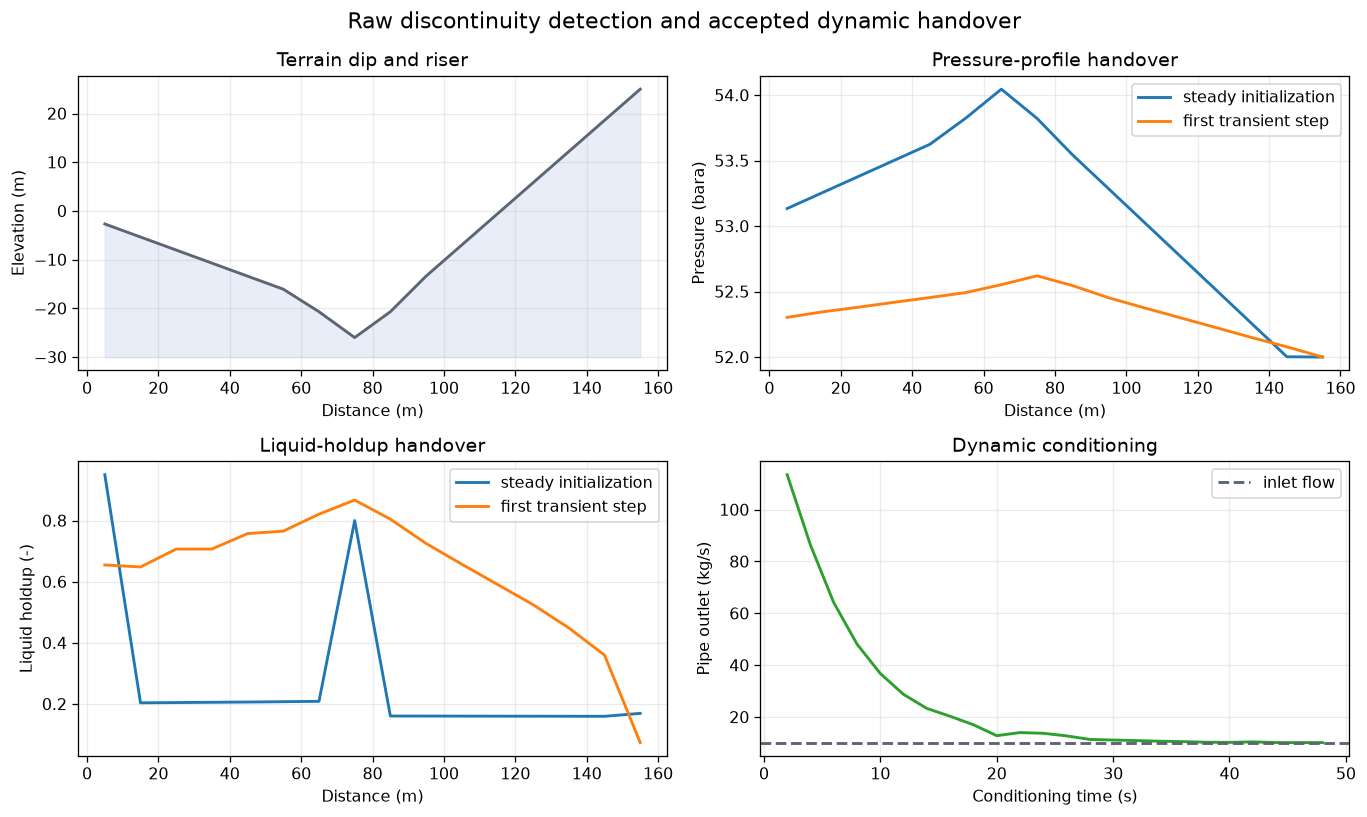

In [8]:
figure, axes = plt.subplots(2, 2, figsize=(12.0, 7.2))

axes[0, 0].plot(position_m, elevation_profile, color=COLORS["gray"])
axes[0, 0].fill_between(
    position_m,
    elevation_profile,
    min(elevation_profile) - 4.0,
    color="#D9E2F3",
    alpha=0.6,
)
axes[0, 0].set_title("Terrain dip and riser")
axes[0, 0].set_xlabel("Distance (m)")
axes[0, 0].set_ylabel("Elevation (m)")

axes[0, 1].plot(
    position_m,
    steady_pressure_bara,
    label="steady initialization",
)
axes[0, 1].plot(
    position_m,
    raw_pressure_bara,
    label="first transient step",
)
axes[0, 1].set_title("Pressure-profile handover")
axes[0, 1].set_xlabel("Distance (m)")
axes[0, 1].set_ylabel("Pressure (bara)")
axes[0, 1].legend()

axes[1, 0].plot(
    position_m,
    steady_holdup,
    label="steady initialization",
)
axes[1, 0].plot(
    position_m,
    raw_holdup,
    label="first transient step",
)
axes[1, 0].set_title("Liquid-holdup handover")
axes[1, 0].set_xlabel("Distance (m)")
axes[1, 0].set_ylabel("Liquid holdup (-)")
axes[1, 0].legend()

axes[1, 1].plot(
    conditioning["time (s)"],
    conditioning["outlet flow (kg/s)"],
    color=COLORS["green"],
)
axes[1, 1].axhline(
    BASE_FLOW_KG_S,
    color=COLORS["gray"],
    linestyle="--",
    label="inlet flow",
)
axes[1, 1].set_title("Dynamic conditioning")
axes[1, 1].set_xlabel("Conditioning time (s)")
axes[1, 1].set_ylabel("Pipe outlet (kg/s)")
axes[1, 1].legend()

figure.suptitle(
    "Raw discontinuity detection and accepted dynamic handover",
    fontsize=14,
)
figure.tight_layout()
plt.show()

## 8. Receiving separator and liquid-level control

The conditioned pipe outlet fluid initializes a native two-phase `Separator`.
The separator is solved once at steady conditions; vessel geometry and initial
level are then assigned before transient mode is enabled.

The liquid controller is a transparent PI draw-off policy acting on the native
`LevelTransmitter`. Its bias equals the steady separator liquid flow. It is
intentionally slower than the incoming liquid variation so the vessel absorbs
terrain and slug-related surges.

$$\begin{aligned}\dot m_{L,out}&=\operatorname{clip}\left[\dot m_{L,0}+K_p e_L+\frac{K_p}{T_i}\int e_L dt\right]\end{aligned}$$

where $e_L=L-L_{sp}$ and $L_{sp}=0.50$.

In [9]:
native_pipe_outlet = pipeline.getOutletStream()
topside_fluid = native_pipe_outlet.getFluid().clone()
topside_feed = Stream("topside separator feed", topside_fluid)
topside_feed.setFlowRate(
    native_pipe_outlet.getFlowRate("kg/sec"),
    "kg/sec",
)
topside_feed.run(new_step_id())

separator = Separator("V-101 receiving separator", topside_feed)
separator.run(new_step_id())
separator.setInternalDiameter(2.0)
separator.setSeparatorLength(6.0)
separator.setLiquidLevel(0.50)
separator.setCalculateSteadyState(False)
level_transmitter = LevelTransmitter("LT-101", separator)

base_separator_gas_kg_s = float(
    separator.getGasOutStream().getFlowRate("kg/sec")
)
base_separator_liquid_kg_s = float(
    separator.getLiquidOutStream().getFlowRate("kg/sec")
)
separator_summary = pd.Series(
    {
        "initial feed (kg/s)": conditioned_total_kg_s,
        "steady gas outlet (kg/s)": base_separator_gas_kg_s,
        "steady liquid outlet (kg/s)": base_separator_liquid_kg_s,
        "initial level (-)": separator.getLiquidLevel(),
        "diameter (m)": separator.getInternalDiameter(),
        "length (m)": separator.getSeparatorLength(),
    },
    name="V-101 initialization",
)
display(separator_summary)

initial feed (kg/s)            10.136931
steady gas outlet (kg/s)        7.868791
steady liquid outlet (kg/s)     2.268140
initial level (-)               0.500000
diameter (m)                    2.000000
length (m)                      6.000000
Name: V-101 initialization, dtype: float64

## 9. Compressor map, pressure control, and anti-surge recycle

`CompressorChartGenerator` creates a five-speed export-compressor map from the
initialized NeqSim machine. Native surge and stonewall curves are activated.

- `PIC-201` reads a native `PressureTransmitter` on compressor discharge and
  changes speed between 7,500 and 10,500 rpm.
  A 5 s derivative term with a 4 s filter damps the current-master response.
- `UIC-202` is NeqSim's predictive `AntiSurgeController` with actuator rate,
  lag, and emergency action.
- actual recycle is a first-order co-simulation state driven by the controller
  request and limited by stonewall capacity.

The target is 90 bara. A temporary surge-line crossing at the start of the
low-flow event is allowed only if the controller detects it, opens recycle,
and returns to a positive final margin. Stonewall crossing is never accepted.

In [10]:
compressor_feed = Stream(
    "K-201 suction",
    separator.getGasOutStream().getFluid().clone(),
)
compressor_feed.setFlowRate(base_separator_gas_kg_s, "kg/sec")
compressor_feed.run(new_step_id())

compressor = Compressor("K-201 export compressor", compressor_feed)
compressor.setOutletPressure(90.0, "bara")
compressor.setUsePolytropicCalc(True)
compressor.setPolytropicEfficiency(0.78)
compressor.setSpeed(9000.0)
compressor.run(new_step_id())

chart_generator = CompressorChartGenerator(compressor)
chart_generator.setChartType("interpolate and extrapolate")
compressor_chart = chart_generator.generateFromTemplate("EXPORT", 5)
compressor_chart.generateSurgeCurve()
compressor_chart.generateStoneWallCurve()
compressor.setCompressorChart(compressor_chart)
compressor.run(new_step_id())

pressure_transmitter = PressureTransmitter(
    "PT-201",
    compressor.getOutletStream(),
)
pressure_transmitter.setUnit("bara")
pressure_controller = Controller("PIC-201")
pressure_controller.setTransmitter(pressure_transmitter)
pressure_controller.setControllerSetPoint(90.0, "bara")
pressure_controller.setControllerParameters(18.0, 60.0, 5.0)
pressure_controller.setDerivativeFilterTime(4.0)
pressure_controller.setReverseActing(True)
pressure_controller.setOutputLimits(7500.0, 10500.0)

recycle_valve = ThrottlingValve(
    "FV-202 anti-surge recycle",
    compressor.getOutletStream(),
)
recycle_valve.setOutletPressure(52.0)
recycle_valve.setPercentValveOpening(0.0)

anti_surge_controller = AntiSurgeController(
    "UIC-202 anti-surge",
    compressor,
    recycle_valve,
)
anti_surge_controller.setSurgeMarginSetPoint(0.12)
anti_surge_controller.setProportionalGain(350.0)
anti_surge_controller.setIntegralTime(15.0)
anti_surge_controller.setOpeningRange(0.0, 100.0)
anti_surge_controller.setPredictiveActionEnabled(True)
anti_surge_controller.setPredictionHorizon(8.0)
anti_surge_controller.setMarginRateFilterTime(4.0)
anti_surge_controller.setActuatorDynamics(25.0, 2.0)
anti_surge_controller.setEmergencyAction(0.02, 80.0)

compressor_summary = pd.Series(
    {
        "design suction flow (kg/s)": base_separator_gas_kg_s,
        "design speed (rpm)": compressor.getSpeed(),
        "design discharge pressure (bara)": (
            compressor.getOutletStream().getPressure("bara")
        ),
        "design surge margin (-)": compressor.getDistanceToSurge(),
        "design stonewall margin (-)": (
            compressor.getDistanceToStoneWall()
        ),
        "map speed curves (-)": len(compressor_chart.getSpeeds()),
    },
    name="K-201 initialized map point",
)
display(compressor_summary)

design suction flow (kg/s)             7.868791
design speed (rpm)                  9000.000000
design discharge pressure (bara)      91.309526
design surge margin (-)                0.513616
design stonewall margin (-)            0.468784
map speed curves (-)                   5.000000
Name: K-201 initialized map point, dtype: float64

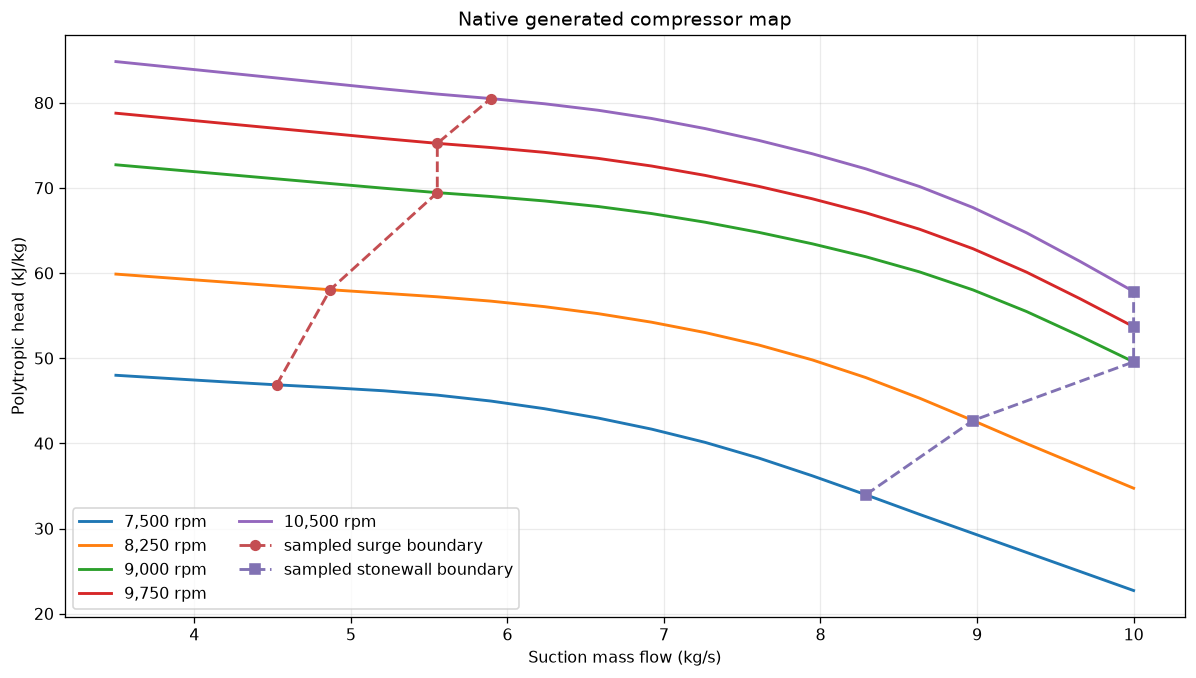

In [11]:
map_speeds = [7500.0, 8250.0, 9000.0, 9750.0, 10500.0]
map_flows_kg_s = np.linspace(3.5, 10.0, 20)
map_records = []
original_flow = compressor_feed.getFlowRate("kg/sec")
original_speed = compressor.getSpeed()

for map_speed in map_speeds:
    for map_flow in map_flows_kg_s:
        compressor_feed.setFlowRate(float(map_flow), "kg/sec")
        compressor_feed.run(new_step_id())
        compressor.setSpeed(map_speed)
        compressor.run(new_step_id())
        map_records.append(
            {
                "speed (rpm)": map_speed,
                "flow (kg/s)": map_flow,
                "head (kJ/kg)": compressor.getPolytropicHead("kJ/kg"),
                "surge margin (-)": compressor.getDistanceToSurge(),
                "stonewall margin (-)": (
                    compressor.getDistanceToStoneWall()
                ),
            }
        )

compressor_map = pd.DataFrame(map_records)
compressor_feed.setFlowRate(original_flow, "kg/sec")
compressor_feed.run(new_step_id())
compressor.setSpeed(original_speed)
compressor.run(new_step_id())

figure, axis = plt.subplots(figsize=(10.5, 6.0))
for map_speed, group in compressor_map.groupby("speed (rpm)"):
    axis.plot(
        group["flow (kg/s)"],
        group["head (kJ/kg)"],
        label=f"{map_speed:,.0f} rpm",
    )
surge_points = compressor_map.iloc[
    (compressor_map["surge margin (-)"].abs())
    .groupby(compressor_map["speed (rpm)"])
    .idxmin()
]
stonewall_points = compressor_map.iloc[
    (compressor_map["stonewall margin (-)"].abs())
    .groupby(compressor_map["speed (rpm)"])
    .idxmin()
]
axis.plot(
    surge_points["flow (kg/s)"],
    surge_points["head (kJ/kg)"],
    "o--",
    color=COLORS["red"],
    label="sampled surge boundary",
)
axis.plot(
    stonewall_points["flow (kg/s)"],
    stonewall_points["head (kJ/kg)"],
    "s--",
    color=COLORS["purple"],
    label="sampled stonewall boundary",
)
axis.set_title("Native generated compressor map")
axis.set_xlabel("Suction mass flow (kg/s)")
axis.set_ylabel("Polytropic head (kJ/kg)")
axis.legend(ncol=2)
figure.tight_layout()
plt.show()

## 10. Deterministic disturbance schedule

The 540 s study includes base operation, a controlled ramp to 35% inlet flow,
120 s at low flow, restart, a short 105% high-flow period, and return to base.
Ramps avoid nonphysical boundary impulses while still challenging transport,
liquid inventory, anti-surge control, and plant-pressure control.

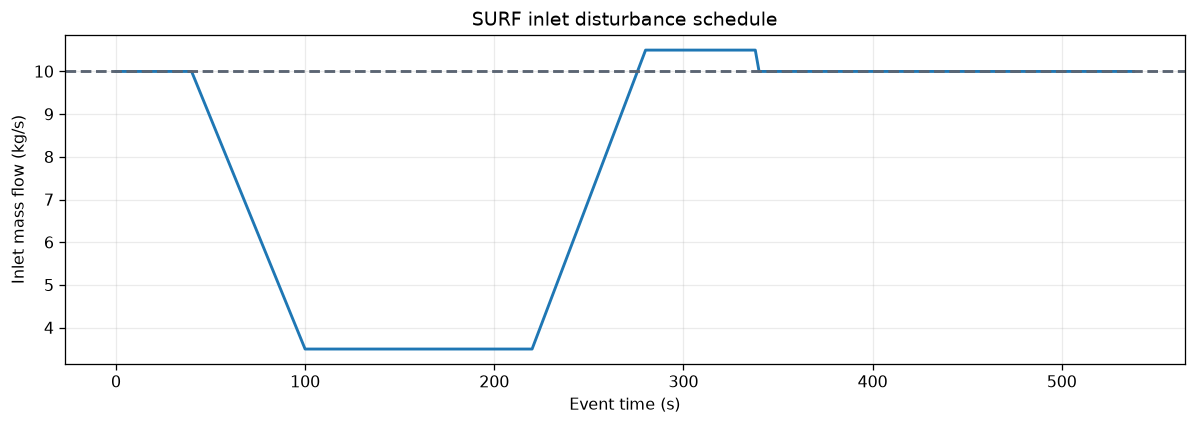

,start_time_s,end_time_s,minimum_flow_kg_s,maximum_flow_kg_s
event,,,,
base,0.0,38.0,10.000000,10.000000
ramp down,40.0,98.0,3.716667,10.000000
low flow,100.0,218.0,3.500000,3.500000
restart ramp,220.0,278.0,3.500000,10.266667
high flow,280.0,338.0,10.500000,10.500000
return to base,340.0,538.0,10.000000,10.000000


In [12]:
def inlet_flow_schedule(time_s):
    if time_s < 40.0:
        return 10.0, "base"
    if time_s < 100.0:
        ramp_fraction = (time_s - 40.0) / 60.0
        return 10.0 - 6.5 * ramp_fraction, "ramp down"
    if time_s < 220.0:
        return 3.5, "low flow"
    if time_s < 280.0:
        ramp_fraction = (time_s - 220.0) / 60.0
        return 3.5 + 7.0 * ramp_fraction, "restart ramp"
    if time_s < 340.0:
        return 10.5, "high flow"
    return 10.0, "return to base"


schedule = pd.DataFrame(
    [
        {
            "time (s)": step * DT_S,
            "inlet flow (kg/s)": inlet_flow_schedule(step * DT_S)[0],
            "event": inlet_flow_schedule(step * DT_S)[1],
        }
        for step in range(270)
    ]
)

figure, axis = plt.subplots(figsize=(10.5, 3.8))
axis.plot(
    schedule["time (s)"],
    schedule["inlet flow (kg/s)"],
    color=COLORS["blue"],
)
axis.axhline(BASE_FLOW_KG_S, color=COLORS["gray"], linestyle="--")
axis.set_title("SURF inlet disturbance schedule")
axis.set_xlabel("Event time (s)")
axis.set_ylabel("Inlet mass flow (kg/s)")
figure.tight_layout()
plt.show()

display(
    schedule.groupby("event", sort=False)
    .agg(
        start_time_s=("time (s)", "min"),
        end_time_s=("time (s)", "max"),
        minimum_flow_kg_s=("inlet flow (kg/s)", "min"),
        maximum_flow_kg_s=("inlet flow (kg/s)", "max"),
    )
)

## 11. Coupled dynamic simulation

The loop uses an explicit staggered exchange suitable for teaching:

1. update the inlet schedule;
2. advance `TwoFluidPipe` and read its native outlet process stream;
3. audit the stream total against phase-resolved conservative fluxes;
4. pass the native stream state and total flow to the dynamic separator;
5. copy separator gas to compressor suction and add recycle;
6. run the native compressor map;
7. update pressure and anti-surge controllers for the next step; and
8. enforce the stonewall low-select override.

The sequence is deterministic and all exchange signals are retained. A real
project should test smaller outer timesteps or use iterative strong coupling
when fast feedback across unit boundaries is important.

In [13]:
simulation_records = []
liquid_controller_integral = 0.0
recycle_flow_kg_s = 0.0
speed_command_rpm = 9000.0
maximum_recycle_kg_s = 4.5

compressor_density_kg_m3 = float(
    compressor_feed.getFluid().getDensity("kg/m3")
)
stonewall_capacity_kg_s = (
    compressor_feed.getFlowRate("m3/hr")
    * (1.0 + compressor.getDistanceToStoneWall())
    * compressor_density_kg_m3
    / 3600.0
)
conservative_stonewall_capacity_kg_s = (
    compressor_chart.getStoneWallFlowAtSpeed(7500.0)
    * compressor_density_kg_m3
    / 3600.0
    * 0.95
)

for simulation_step in range(270):
    time_s = simulation_step * DT_S
    requested_flow_kg_s, event = inlet_flow_schedule(time_s)
    step_id = new_step_id()

    pipe_inlet.setFlowRate(requested_flow_kg_s, "kg/sec")
    pipe_inlet.run(step_id)
    pipeline.runTransient(DT_S, step_id)
    mass_report = pipeline.getLastMassBalanceReport()
    report_elapsed_s = mass_report.getElapsedTimeSeconds()
    native_pipe_outlet = pipeline.getOutletStream()
    pipe_total_kg_s = float(
        native_pipe_outlet.getFlowRate("kg/sec")
    )
    report_total_kg_s = (
        mass_report.getOutletMassKg(Phase.TOTAL)
        / report_elapsed_s
    )
    pipe_gas_kg_s = (
        mass_report.getOutletMassKg(Phase.GAS)
        / report_elapsed_s
    )
    pipe_liquid_kg_s = (
        mass_report.getOutletMassKg(Phase.LIQUID)
        / report_elapsed_s
    )
    stream_report_error_kg_s = abs(
        pipe_total_kg_s - report_total_kg_s
    )
    phase_sum_error_kg_s = abs(
        pipe_gas_kg_s + pipe_liquid_kg_s - report_total_kg_s
    )

    topside_feed.setThermoSystem(
        native_pipe_outlet.getFluid().clone()
    )
    topside_feed.setFlowRate(max(pipe_total_kg_s, 0.05), "kg/sec")
    topside_feed.run(step_id)

    separator_level_before = float(separator.getLiquidLevel())
    level_error = separator_level_before - 0.50
    candidate_integral = (
        liquid_controller_integral + level_error * DT_S
    )
    liquid_draw_kg_s = (
        base_separator_liquid_kg_s
        + 4.0 * level_error
        + 4.0 / 120.0 * candidate_integral
    )
    minimum_liquid_draw = 0.05 * base_separator_liquid_kg_s
    maximum_liquid_draw = 3.0 * base_separator_liquid_kg_s
    liquid_draw_kg_s = min(
        maximum_liquid_draw,
        max(minimum_liquid_draw, liquid_draw_kg_s),
    )
    if minimum_liquid_draw < liquid_draw_kg_s < maximum_liquid_draw:
        liquid_controller_integral = candidate_integral

    separator.getGasOutStream().setFlowRate(
        max(pipe_gas_kg_s, 0.05),
        "kg/sec",
    )
    separator.getLiquidOutStream().setFlowRate(
        liquid_draw_kg_s,
        "kg/sec",
    )
    separator.runTransient(DT_S, step_id)

    fresh_gas_kg_s = float(
        separator.getGasOutStream().getFlowRate("kg/sec")
    )
    available_stonewall_capacity = min(
        0.95 * stonewall_capacity_kg_s,
        conservative_stonewall_capacity_kg_s,
    )
    pre_run_recycle_limit = max(
        0.0,
        available_stonewall_capacity - fresh_gas_kg_s,
    )
    recycle_flow_kg_s = min(
        recycle_flow_kg_s,
        pre_run_recycle_limit,
    )

    compressor_feed.setThermoSystem(
        separator.getGasOutStream().getFluid().clone()
    )
    compressor_feed.setFlowRate(
        max(fresh_gas_kg_s + recycle_flow_kg_s, 0.1),
        "kg/sec",
    )
    compressor_feed.run(step_id)
    compressor.setSpeed(speed_command_rpm)
    compressor.run(step_id)

    compressor_density_kg_m3 = float(
        compressor_feed.getFluid().getDensity("kg/m3")
    )
    stonewall_capacity_kg_s = (
        compressor_feed.getFlowRate("m3/hr")
        * (1.0 + compressor.getDistanceToStoneWall())
        * compressor_density_kg_m3
        / 3600.0
    )

    pressure_controller.runTransient(
        compressor.getSpeed(),
        DT_S,
        step_id,
    )
    speed_command_rpm = float(pressure_controller.getResponse())
    anti_surge_controller.runTransient(
        anti_surge_controller.getValveOpening(),
        DT_S,
        step_id,
    )
    recycle_request_kg_s = (
        maximum_recycle_kg_s
        * float(anti_surge_controller.getValveOpening())
        / 100.0
    )
    available_stonewall_capacity = min(
        0.95 * stonewall_capacity_kg_s,
        conservative_stonewall_capacity_kg_s,
    )
    recycle_limit_kg_s = max(
        0.0,
        available_stonewall_capacity - fresh_gas_kg_s,
    )
    recycle_target_kg_s = min(
        recycle_request_kg_s,
        recycle_limit_kg_s,
    )
    recycle_flow_kg_s += min(1.0, DT_S / 6.0) * (
        recycle_target_kg_s - recycle_flow_kg_s
    )
    recycle_flow_kg_s = min(
        recycle_flow_kg_s,
        recycle_limit_kg_s,
    )
    actual_recycle_opening = (
        100.0 * recycle_flow_kg_s / maximum_recycle_kg_s
    )
    recycle_valve.setPercentValveOpening(actual_recycle_opening)
    recycle_override_active = (
        recycle_request_kg_s > recycle_limit_kg_s + 1.0e-9
    )

    accumulation_m3 = float(
        pipeline.getAccumulationTracker().getTotalAccumulatedVolume()
    )
    slug_tracker = pipeline.getLagrangianSlugTracker()
    simulation_records.append(
        {
            "time (s)": time_s,
            "event": event,
            "inlet flow (kg/s)": requested_flow_kg_s,
            "pipe outlet (kg/s)": pipe_total_kg_s,
            "report outlet (kg/s)": report_total_kg_s,
            "stream/report error (kg/s)": (
                stream_report_error_kg_s
            ),
            "phase-sum error (kg/s)": phase_sum_error_kg_s,
            "pipe gas outlet (kg/s)": pipe_gas_kg_s,
            "pipe liquid outlet (kg/s)": pipe_liquid_kg_s,
            "topside feed (kg/s)": float(
                topside_feed.getFlowRate("kg/sec")
            ),
            "pipe inventory (kg)": float(
                pipeline.getTotalMassInventory()
            ),
            "terrain accumulation (m3)": accumulation_m3,
            "active slugs (-)": int(slug_tracker.getSlugCount()),
            "slugs generated (-)": int(
                slug_tracker.getTotalSlugsGenerated()
            ),
            "slugs exited (-)": int(
                slug_tracker.getTotalSlugsExited()
            ),
            "slug mass error (kg)": float(
                slug_tracker.getMassConservationError()
            ),
            "slug mass exited (kg)": float(
                slug_tracker.getTotalMassExitedAtOutlet()
            ),
            "pipe mass residual (-)": float(
                mass_report.getRelativeResidual(Phase.TOTAL)
            ),
            "separator level (-)": float(
                level_transmitter.getMeasuredValue()
            ),
            "separator pressure (bara)": float(separator.getPressure()),
            "liquid draw (kg/s)": liquid_draw_kg_s,
            "fresh gas (kg/s)": fresh_gas_kg_s,
            "recycle (kg/s)": recycle_flow_kg_s,
            "compressor flow (kg/s)": float(
                compressor_feed.getFlowRate("kg/sec")
            ),
            "discharge pressure (bara)": float(
                compressor.getOutletStream().getPressure("bara")
            ),
            "speed (rpm)": float(compressor.getSpeed()),
            "surge margin (-)": float(
                compressor.getDistanceToSurge()
            ),
            "stonewall margin (-)": float(
                compressor.getDistanceToStoneWall()
            ),
            "anti-surge request (%)": float(
                anti_surge_controller.getValveOpening()
            ),
            "anti-surge opening (%)": actual_recycle_opening,
            "recycle override active": recycle_override_active,
            "power (kW)": float(compressor.getPower("kW")),
            "step UUID": str(step_id),
        }
    )

results = pd.DataFrame(simulation_records)
print(
    f"Completed {len(results)} physical timesteps with "
    f"{results['step UUID'].nunique()} unique IDs."
)

Completed 270 physical timesteps with 270 unique IDs.


## 12. Dynamic response

The first dashboard connects the transport and vessel layers. It makes the
finite pipe response, terrain-liquid movement, tracked slug count, and vessel
buffering visible on the same time basis.

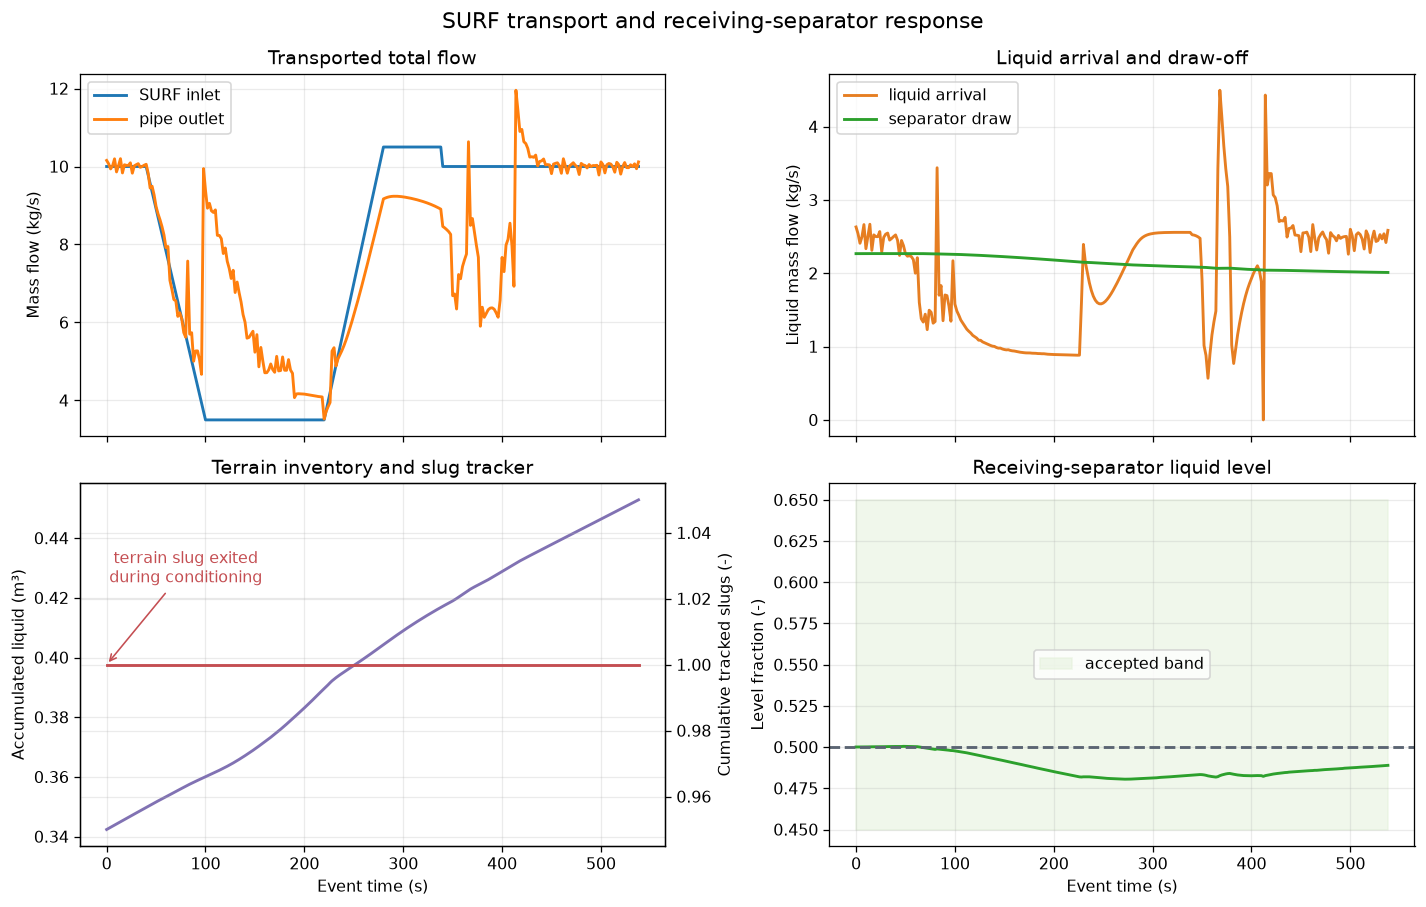

In [14]:
figure, axes = plt.subplots(2, 2, figsize=(12.5, 8.0), sharex=True)
time_s = results["time (s)"]

axes[0, 0].plot(
    time_s,
    results["inlet flow (kg/s)"],
    label="SURF inlet",
)
axes[0, 0].plot(
    time_s,
    results["pipe outlet (kg/s)"],
    label="pipe outlet",
)
axes[0, 0].set_title("Transported total flow")
axes[0, 0].set_ylabel("Mass flow (kg/s)")
axes[0, 0].legend()

axes[0, 1].plot(
    time_s,
    results["pipe liquid outlet (kg/s)"],
    color=COLORS["orange"],
    label="liquid arrival",
)
axes[0, 1].plot(
    time_s,
    results["liquid draw (kg/s)"],
    color=COLORS["green"],
    label="separator draw",
)
axes[0, 1].set_title("Liquid arrival and draw-off")
axes[0, 1].set_ylabel("Liquid mass flow (kg/s)")
axes[0, 1].legend()

axes[1, 0].plot(
    time_s,
    results["terrain accumulation (m3)"],
    color=COLORS["purple"],
    label="terrain accumulation",
)
slug_axis = axes[1, 0].twinx()
slug_axis.step(
    time_s,
    results["slugs exited (-)"],
    where="post",
    color=COLORS["red"],
    label="tracked slugs exited",
)
if results["slugs exited (-)"].iloc[0] > 0:
    slug_axis.annotate(
        "terrain slug exited\nduring conditioning",
        xy=(time_s.iloc[0], results["slugs exited (-)"].iloc[0]),
        xytext=(80.0, results["slugs exited (-)"].iloc[0] + 0.025),
        ha="center",
        color=COLORS["red"],
        arrowprops={"arrowstyle": "->", "color": COLORS["red"]},
    )
axes[1, 0].set_title("Terrain inventory and slug tracker")
axes[1, 0].set_xlabel("Event time (s)")
axes[1, 0].set_ylabel("Accumulated liquid (m³)")
slug_axis.set_ylabel("Cumulative tracked slugs (-)")

axes[1, 1].plot(
    time_s,
    results["separator level (-)"],
    color=COLORS["green"],
)
axes[1, 1].axhline(0.50, color=COLORS["gray"], linestyle="--")
axes[1, 1].fill_between(
    time_s,
    0.45,
    0.65,
    color="#E2F0D9",
    alpha=0.5,
    label="accepted band",
)
axes[1, 1].set_title("Receiving-separator liquid level")
axes[1, 1].set_xlabel("Event time (s)")
axes[1, 1].set_ylabel("Level fraction (-)")
axes[1, 1].legend()

figure.suptitle("SURF transport and receiving-separator response", fontsize=14)
figure.tight_layout()
plt.show()

The second dashboard focuses on plant controls. A negative surge
margin during the initial low-flow approach is reported rather than hidden.
The anti-surge request opens recycle, the margin recovers, and the valve closes
after return to base. The stonewall override acts only when the simultaneous
fresh and requested recycle flow would violate the native map capacity.

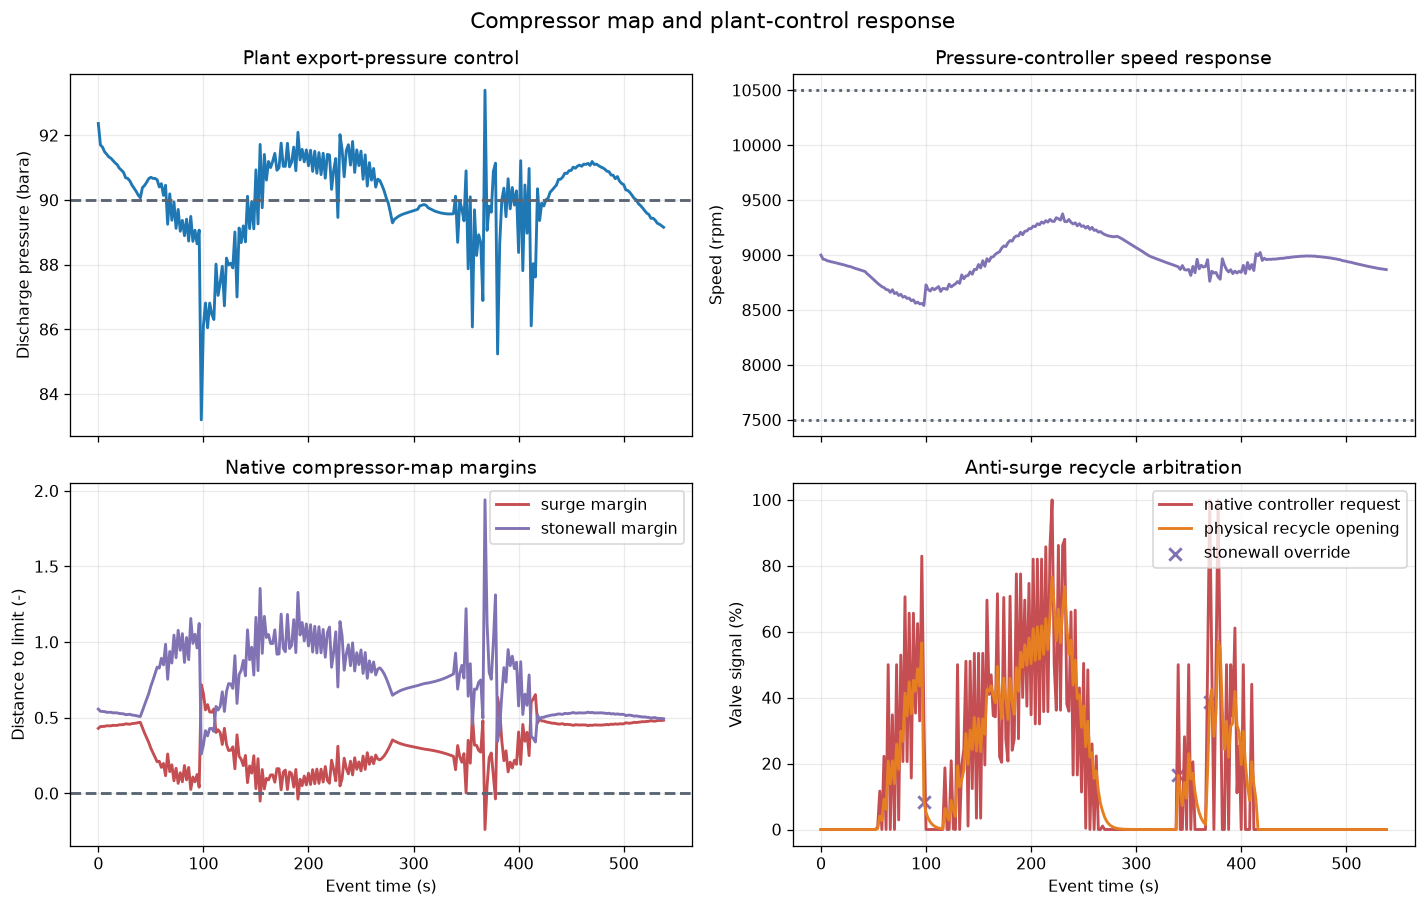

In [15]:
figure, axes = plt.subplots(2, 2, figsize=(12.5, 8.0), sharex=True)

axes[0, 0].plot(
    time_s,
    results["discharge pressure (bara)"],
    color=COLORS["blue"],
)
axes[0, 0].axhline(90.0, color=COLORS["gray"], linestyle="--")
axes[0, 0].set_title("Plant export-pressure control")
axes[0, 0].set_ylabel("Discharge pressure (bara)")

axes[0, 1].plot(
    time_s,
    results["speed (rpm)"],
    color=COLORS["purple"],
)
axes[0, 1].axhline(7500.0, color=COLORS["gray"], linestyle=":")
axes[0, 1].axhline(10500.0, color=COLORS["gray"], linestyle=":")
axes[0, 1].set_title("Pressure-controller speed response")
axes[0, 1].set_ylabel("Speed (rpm)")

axes[1, 0].plot(
    time_s,
    results["surge margin (-)"],
    color=COLORS["red"],
    label="surge margin",
)
axes[1, 0].plot(
    time_s,
    results["stonewall margin (-)"],
    color=COLORS["purple"],
    label="stonewall margin",
)
axes[1, 0].axhline(0.0, color=COLORS["gray"], linestyle="--")
axes[1, 0].set_title("Native compressor-map margins")
axes[1, 0].set_xlabel("Event time (s)")
axes[1, 0].set_ylabel("Distance to limit (-)")
axes[1, 0].legend()

axes[1, 1].plot(
    time_s,
    results["anti-surge request (%)"],
    color=COLORS["red"],
    label="native controller request",
)
axes[1, 1].plot(
    time_s,
    results["anti-surge opening (%)"],
    color=COLORS["orange"],
    label="physical recycle opening",
)
override_rows = results["recycle override active"]
axes[1, 1].scatter(
    time_s[override_rows],
    results.loc[override_rows, "anti-surge opening (%)"],
    marker="x",
    s=60,
    color=COLORS["purple"],
    label="stonewall override",
)
axes[1, 1].set_title("Anti-surge recycle arbitration")
axes[1, 1].set_xlabel("Event time (s)")
axes[1, 1].set_ylabel("Valve signal (%)")
axes[1, 1].legend()

figure.suptitle("Compressor map and plant-control response", fontsize=14)
figure.tight_layout()
plt.show()

## 13. Event summary, transport delay, and multiphase error scan

Transport delay is estimated by maximizing the correlation between inlet flow
and the later pipe-outlet response over non-negative lags from 0 to 120 s.
This event-shape diagnostic is more robust than a threshold crossing when the
outlet already oscillates around the threshold. It is not a residence-time
distribution.

At every timestep, three independent coupling checks are retained: native pipe
stream to conservative report, gas-plus-liquid phase closure, and pipe stream
to separator feed. The corrected Lagrangian ledger is also checked after the
tracked slug has exited. Any non-finite value or tolerance breach fails the
named gates below instead of being hidden by the orchestration layer.

In [16]:
event_summary = (
    results.groupby("event", sort=False)
    .agg(
        inlet_min_kg_s=("inlet flow (kg/s)", "min"),
        inlet_max_kg_s=("inlet flow (kg/s)", "max"),
        pipe_out_min_kg_s=("pipe outlet (kg/s)", "min"),
        pipe_out_max_kg_s=("pipe outlet (kg/s)", "max"),
        level_min=("separator level (-)", "min"),
        level_max=("separator level (-)", "max"),
        pressure_min_bara=("discharge pressure (bara)", "min"),
        pressure_max_bara=("discharge pressure (bara)", "max"),
        surge_margin_min=("surge margin (-)", "min"),
        asv_opening_max=("anti-surge opening (%)", "max"),
    )
    .round(4)
)
display(event_summary)

inlet_values = results["inlet flow (kg/s)"].to_numpy()
outlet_values = results["pipe outlet (kg/s)"].to_numpy()
lag_records = []
for lag_steps in range(61):
    if lag_steps == 0:
        inlet_slice = inlet_values
        outlet_slice = outlet_values
    else:
        inlet_slice = inlet_values[:-lag_steps]
        outlet_slice = outlet_values[lag_steps:]
    correlation = float(np.corrcoef(inlet_slice, outlet_slice)[0, 1])
    lag_records.append(
        {
            "lag steps (-)": lag_steps,
            "lag (s)": lag_steps * DT_S,
            "correlation (-)": correlation,
        }
    )

lag_scan = pd.DataFrame(lag_records)
best_lag_row = lag_scan.loc[lag_scan["correlation (-)"].idxmax()]
transport_delay_s = float(best_lag_row["lag (s)"])
transport_correlation = float(best_lag_row["correlation (-)"])

maximum_interface_error_kg_s = float(
    np.max(
        np.abs(
            results["pipe outlet (kg/s)"]
            - results["topside feed (kg/s)"]
        )
    )
)
maximum_stream_report_error_kg_s = float(
    results["stream/report error (kg/s)"].max()
)
maximum_phase_sum_error_kg_s = float(
    results["phase-sum error (kg/s)"].max()
)
final_slug_mass_error_kg = abs(
    float(results["slug mass error (kg)"].iloc[-1])
)
slug_mass_exited_kg = float(
    results["slug mass exited (kg)"].iloc[-1]
)
pressure_event_count = len(pressure_controller.getEventLog())

diagnostic_summary = pd.Series(
    {
        "best lag-correlation delay (s)": transport_delay_s,
        "best lag correlation (-)": transport_correlation,
        "maximum stream→report error (kg/s)": (
            maximum_stream_report_error_kg_s
        ),
        "maximum phase-sum error (kg/s)": (
            maximum_phase_sum_error_kg_s
        ),
        "maximum pipe→topside error (kg/s)": (
            maximum_interface_error_kg_s
        ),
        "native pressure-controller events (-)": pressure_event_count,
        "native slug mass error (kg)": final_slug_mass_error_kg,
        "tracked slug mass exited (kg)": slug_mass_exited_kg,
    },
    name="coupling diagnostics",
)
display(diagnostic_summary)

,inlet_min_kg_s,inlet_max_kg_s,pipe_out_min_kg_s,pipe_out_max_kg_s,level_min,level_max,pressure_min_bara,pressure_max_bara,surge_margin_min,asv_opening_max
event,,,,,,,,,,
base,10.0000,10.0000,9.8293,10.2005,0.5001,0.5004,90.1558,92.3692,0.4299,0.0000
ramp down,3.7167,10.0000,4.6689,10.0566,0.4979,0.5005,83.2006,90.7050,0.0262,56.6417
low flow,3.5000,3.5000,4.0721,9.3881,0.4830,0.4977,86.0526,92.0955,-0.0509,64.9732
restart ramp,3.5000,10.2667,3.5221,8.9604,0.4805,0.4827,89.4628,92.0249,0.0498,76.6488
high flow,10.5000,10.5000,8.9060,9.2377,0.4807,0.4828,89.2963,89.8640,0.2449,0.4932
return to base,10.0000,10.0000,5.9032,11.9561,0.4818,0.4889,85.2401,93.3973,-0.2386,57.0119


best lag-correlation delay (s)           1.000000e+01
best lag correlation (-)                 7.787038e-01
maximum stream→report error (kg/s)       2.131628e-14
maximum phase-sum error (kg/s)           1.776357e-15
maximum pipe→topside error (kg/s)        3.552714e-15
native pressure-controller events (-)    2.700000e+02
native slug mass error (kg)              5.115908e-13
tracked slug mass exited (kg)            4.031249e+02
Name: coupling diagnostics, dtype: float64

## 14. Named engineering gates

These gates separate expected diagnostic failure from accepted operation:

- the *raw* handover must be detected as discontinuous;
- the *conditioned* handover must pass five consecutive continuity steps;
- the native outlet stream, phase fluxes, and downstream feed must agree;
- the corrected Lagrangian slug ledger must close after outlet exit;
- terrain and slug tracking must be active;
- separator level and compressor map constraints must remain bounded;
- anti-surge must act and then close; and
- pressure control must recover near target.

The transient may cross the surge line briefly before recycle arrives. This is
reported as an event-response metric. It is not permission for a real machine
to enter surge; an equipment study needs vendor transient limits, trip logic,
actuator dynamics, and a validated recycle network.

In [17]:
final_pressure_error_bara = abs(
    results["discharge pressure (bara)"].iloc[-1] - 90.0
)
terrain_accumulation_range_m3 = (
    results["terrain accumulation (m3)"].max()
    - results["terrain accumulation (m3)"].min()
)
level_range = (
    results["separator level (-)"].max()
    - results["separator level (-)"].min()
)
final_surge_margin = results["surge margin (-)"].iloc[-1]
maximum_asv_opening = results["anti-surge opening (%)"].max()
final_asv_opening = results["anti-surge opening (%)"].iloc[-1]
low_flow_endpoint_margin = results.loc[
    results["time (s)"] < 220.0,
    "surge margin (-)",
].iloc[-1]

gate_definitions = [
    (
        "source-built JAR loaded",
        loaded_jar == jar_path.resolve(),
        str(loaded_jar),
    ),
    (
        "raw sharp handover detected",
        raw_discontinuity_detected,
        raw_status,
    ),
    (
        "raw mass report remained conservative",
        raw_metrics["relative mass residual (-)"] < 1.0e-10,
        raw_metrics["relative mass residual (-)"],
    ),
    (
        "conditioned handover accepted",
        conditioned_handover_accepted,
        conditioning["time (s)"].iloc[-1],
    ),
    (
        "one unique UUID per event step",
        results["step UUID"].nunique() == len(results),
        results["step UUID"].nunique(),
    ),
    (
        "pipe discrete mass residual",
        results["pipe mass residual (-)"].max() < 1.0e-10,
        results["pipe mass residual (-)"].max(),
    ),
    (
        "native outlet stream matches conservative report",
        maximum_stream_report_error_kg_s < 1.0e-9,
        maximum_stream_report_error_kg_s,
    ),
    (
        "multiphase gas and liquid sum to total outlet",
        maximum_phase_sum_error_kg_s < 1.0e-10,
        maximum_phase_sum_error_kg_s,
    ),
    (
        "pipe-to-topside flux closure",
        maximum_interface_error_kg_s < 1.0e-12,
        maximum_interface_error_kg_s,
    ),
    (
        "finite correlated transport delay",
        (
            0.0 < transport_delay_s < 180.0
            and transport_correlation > 0.50
        ),
        (transport_delay_s, transport_correlation),
    ),
    (
        "terrain accumulation changed",
        terrain_accumulation_range_m3 > 0.05,
        terrain_accumulation_range_m3,
    ),
    (
        "native slug tracker recorded an exit",
        results["slugs exited (-)"].iloc[-1] >= 1,
        results["slugs exited (-)"].iloc[-1],
    ),
    (
        "slug tracker mass ledger closed",
        final_slug_mass_error_kg < 1.0e-8,
        final_slug_mass_error_kg,
    ),
    (
        "slug outlet mass recorded after exit",
        slug_mass_exited_kg > 0.0,
        slug_mass_exited_kg,
    ),
    (
        "separator level inside operating band",
        (
            results["separator level (-)"].min() >= 0.45
            and results["separator level (-)"].max() <= 0.65
        ),
        (
            results["separator level (-)"].min(),
            results["separator level (-)"].max(),
        ),
    ),
    (
        "separator visibly buffered liquid",
        level_range > 0.01,
        level_range,
    ),
    (
        "compressor results finite and positive",
        (
            np.isfinite(results["power (kW)"]).all()
            and (results["power (kW)"] > 0.0).all()
        ),
        results["power (kW)"].min(),
    ),
    (
        "native anti-surge controller acted",
        maximum_asv_opening > 20.0,
        maximum_asv_opening,
    ),
    (
        "low-flow endpoint surge margin positive",
        low_flow_endpoint_margin > 0.08,
        low_flow_endpoint_margin,
    ),
    (
        "anti-surge recycle closed after recovery",
        final_asv_opening < 5.0,
        final_asv_opening,
    ),
    (
        "final surge margin positive",
        final_surge_margin > 0.12,
        final_surge_margin,
    ),
    (
        "stonewall margin remained positive",
        results["stonewall margin (-)"].min() > 0.05,
        results["stonewall margin (-)"].min(),
    ),
    (
        "pressure controller stayed in speed limits",
        (
            results["speed (rpm)"].min() >= 7500.0
            and results["speed (rpm)"].max() <= 10500.0
        ),
        (
            results["speed (rpm)"].min(),
            results["speed (rpm)"].max(),
        ),
    ),
    (
        "pressure recovered to target",
        final_pressure_error_bara < 1.5,
        final_pressure_error_bara,
    ),
    (
        "native pressure-controller log complete",
        pressure_event_count == len(results),
        pressure_event_count,
    ),
    (
        "stonewall override was sparse",
        results["recycle override active"].sum() <= 5,
        int(results["recycle override active"].sum()),
    ),
]

engineering_gates = pd.DataFrame(
    [
        {"gate": name, "passed": bool(passed), "evidence": evidence}
        for name, passed, evidence in gate_definitions
    ]
)
display(engineering_gates)
failed_gates = engineering_gates.loc[
    ~engineering_gates["passed"],
    ["gate", "evidence"],
]
if not failed_gates.empty:
    raise AssertionError(failed_gates.to_dict("records"))
print(f"ALL {len(engineering_gates)} ENGINEERING GATES PASSED")

ALL 26 ENGINEERING GATES PASSED


,gate,passed,evidence
0,source-built JAR loaded,True,/workspace/scratch/3a96a9f11937/NeqSim-Colab/n...
1,raw sharp handover detected,True,SHARP_HANDOVER_DETECTED
2,raw mass report remained conservative,True,0.0
3,conditioned handover accepted,True,48.0
4,one unique UUID per event step,True,270
5,pipe discrete mass residual,True,0.0
6,native outlet stream matches conservative report,True,0.0
7,multiphase gas and liquid sum to total outlet,True,0.0
8,pipe-to-topside flux closure,True,0.0
9,finite correlated transport delay,True,"(10.0, 0.7787038475070964)"


## 15. Reproducible evidence snapshot

The final object is compact enough for a review or CI artifact. It includes
source provenance, handover classification, core extrema, controller activity,
and gate counts. The full time series remains in `results`.

In [18]:
evidence_snapshot = {
    "status": "CALCULATED_ACCEPTED",
    "neqsim_source": {
        "repository": NEQSIM_REPOSITORY,
        "requested_ref": NEQSIM_SOURCE_REF,
        "resolved_commit": source_commit,
        "jar_sha256": jar_sha256,
        "loaded_jar": str(loaded_jar),
    },
    "handover": {
        "raw_status": raw_status,
        "raw_outlet_feed_ratio": raw_metrics[
            "outlet/feed ratio (-)"
        ],
        "conditioning_time_s": float(
            conditioning["time (s)"].iloc[-1]
        ),
        "accepted": bool(conditioned_handover_accepted),
    },
    "dynamic_run": {
        "timesteps": len(results),
        "unique_step_ids": results["step UUID"].nunique(),
        "maximum_pipe_relative_residual": float(
            results["pipe mass residual (-)"].max()
        ),
        "maximum_stream_report_error_kg_s": (
            maximum_stream_report_error_kg_s
        ),
        "maximum_phase_sum_error_kg_s": (
            maximum_phase_sum_error_kg_s
        ),
        "final_slug_mass_error_kg": final_slug_mass_error_kg,
        "slug_mass_exited_kg": slug_mass_exited_kg,
        "transport_delay_s": transport_delay_s,
        "transport_correlation": transport_correlation,
        "terrain_accumulation_range_m3": float(
            terrain_accumulation_range_m3
        ),
        "slugs_exited": int(results["slugs exited (-)"].iloc[-1]),
        "separator_level_range": [
            float(results["separator level (-)"].min()),
            float(results["separator level (-)"].max()),
        ],
        "minimum_stonewall_margin": float(
            results["stonewall margin (-)"].min()
        ),
        "maximum_physical_recycle_opening_percent": float(
            maximum_asv_opening
        ),
        "final_discharge_pressure_bara": float(
            results["discharge pressure (bara)"].iloc[-1]
        ),
    },
    "engineering_gates": {
        "passed": int(engineering_gates["passed"].sum()),
        "failed": int((~engineering_gates["passed"]).sum()),
    },
    "validated_upstream_corrections": [
        "https://github.com/equinor/neqsim/pull/2815",
        "https://github.com/equinor/neqsim/pull/2816",
    ],
}
print(json.dumps(evidence_snapshot, indent=2))

{
  "status": "CALCULATED_ACCEPTED",
  "neqsim_source": {
    "repository": "https://github.com/equinor/neqsim.git",
    "requested_ref": "master",
    "resolved_commit": "7ae08253b45180045a99a700314f23c9a7001b3c",
    "jar_sha256": "174ba787649c63b3d709ce439bd326284aa91861adaaf6b8d164816ce3c7db3c",
    "loaded_jar": "/workspace/scratch/3a96a9f11937/NeqSim-Colab/neqsim-java-master/target/neqsim-3.16.0.jar"
  },
  "handover": {
    "raw_status": "SHARP_HANDOVER_DETECTED",
    "raw_outlet_feed_ratio": 16.704009183699604,
    "conditioning_time_s": 48.0,
    "accepted": true
  },
  "dynamic_run": {
    "timesteps": 270,
    "unique_step_ids": 270,
    "maximum_pipe_relative_residual": 1.397802335633268e-15,
    "maximum_stream_report_error_kg_s": 2.1316282072803006e-14,
    "maximum_phase_sum_error_kg_s": 1.7763568394002505e-15,
    "final_slug_mass_error_kg": 5.115907697472721e-13,
    "slug_mass_exited_kg": 403.12494407970115,
    "transport_delay_s": 10.0,
    "transport_correlation": 

## Results and engineering interpretation

This solved case makes two different outcomes explicit:

1. **Raw handover:** the first transient step is conservative but discontinuous.
   The notebook detects the sharp outlet, inventory, pressure, and holdup
   changes and refuses to call that state ready.
2. **Conditioned handover:** unchanged-boundary transient steps establish a
   continuous dynamic state before the topside is connected.

During the event schedule, the native `TwoFluidPipe` outlet process stream
transports the disturbance directly into the separator. Its published total
flow agrees with the phase-resolved conservative report, while gas plus liquid
closes to the report total. Terrain accumulation changes and the tracked slug
exits with a closed Lagrangian mass ledger, validating the correction merged in
[NeqSim PR #2815](https://github.com/equinor/neqsim/pull/2815).

The receiving separator buffers the phase-flow variation while its level
controller varies draw-off. At low gas flow the native anti-surge controller
requests recycle. During restart, a sparse low-select override prevents the
combined fresh and recycle flow from crossing the native stonewall curve. The
speed controller then restores export pressure and the recycle closes.

The process result is `CALCULATED_ACCEPTED` for this educational model because
every named gate passes. The corrected native outlet-stream contract from
[NeqSim PR #2816](https://github.com/equinor/neqsim/pull/2816) is used directly.
This remains a compact synthetic study, not a field control design.

## Limitations and required project extensions

- The 160 m route is a compact dynamic demonstrator, not a field-length SURF
  model. Re-tune spatial and temporal resolution for a real line.
- The rich fluid is synthetic. Replace it with governed PVT, water, salts,
  solids, and validated phase-behaviour data.
- The outer coupling is explicit and staggered. Perform timestep convergence
  and consider iterative strong coupling for fast feedback.
- The separator gas draw is matched to the pipe gas boundary flux; a real
  model should include inlet choke, gas-valve capacity, downstream header
  volume, and pressure-control topology.
- Recycle is represented as a first-order flow state. Add recycle piping,
  cooler, check valve, compressor discharge volume, and actuator stroking.
- The generated compressor chart is a teaching map. Vendor-corrected maps,
  speed limits, driver torque, temperature limits, trip logic, and uncertainty
  are required for machinery decisions.
- A temporary calculated surge crossing triggers emergency action here. Real
  acceptance requires vendor-approved transient criteria and protective logic.
- Terrain slug tracking is deterministic and simplified. Benchmark frequency,
  holdup, and slug volume against field data or a trusted high-fidelity model.

## Resolved upstream corrections validated here

- [NeqSim issue #2813](https://github.com/equinor/neqsim/issues/2813) is closed
  by [PR #2815](https://github.com/equinor/neqsim/pull/2815). This notebook
  requires the corrected Lagrangian mass ledger to close after slug exit.
- [NeqSim issue #2814](https://github.com/equinor/neqsim/issues/2814) is closed
  by [PR #2816](https://github.com/equinor/neqsim/pull/2816). This notebook
  couples `TwoFluidPipe.getOutletStream()` directly and requires its total flow
  to match the accepted conservative report at every timestep.

## Exercises

1. Double the pipe sections and halve the outer timestep. Compare transport
   delay, mass residual, slug count, and control extrema.
2. Extend the low-flow hold to 300 s and quantify separator liquid capacity.
3. Remove the stonewall override and explain the resulting map violation.
4. Replace the PI level policy with a native controller and throttling-valve
   capacity model.
5. Add water with a three-phase separator and independent oil/water levels.
6. Add export-header volume and pressure feedback to the compressor suction.

## Troubleshooting

- If the loaded class location is not the source-built JAR, restart the runtime
  and run the setup cell before importing any NeqSim module.
- If Maven fails, confirm Java 17+ and outbound access to Maven Central.
- If conditioning never accepts, inspect the raw profile jumps, reduce the
  outer timestep, and verify boundary conditions before relaxing limits.
- If the map returns non-finite margins, confirm that the generated surge and
  stonewall curves are active and the operating point is inside the sampled
  speed range.

## References

- [NeqSim source repository](https://github.com/equinor/neqsim)
- [`TwoFluidPipe` source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/equipment/pipeline/TwoFluidPipe.java)
- [`TwoFluidMassBalanceReport` source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/equipment/pipeline/TwoFluidMassBalanceReport.java)
- [`Separator` source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/equipment/separator/Separator.java)
- [`Compressor` source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/equipment/compressor/Compressor.java)
- [`AntiSurgeController` source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/controllerdevice/AntiSurgeController.java)
- [Lagrangian tracker correction PR #2815](https://github.com/equinor/neqsim/pull/2815)
- [Transient outlet-stream correction PR #2816](https://github.com/equinor/neqsim/pull/2816)